# RF / SHAP feature-selection analysis

Per contagion threshold, selects a robust feature set and trains an RF
regressor on spread size (`fraction_above_x`).

**Selection logic** (run once per seed in `SEEDS`):
1. Rank all features by SHAP importance.
2. Cluster features by correlation (`|r| >= CORR_THRESHOLD` => same cluster).
3. Keep the most important feature in each cluster.

**Outputs**, per `threshold_<tv>/`:
- aggregates across seeds (the point of running many seeds):
  - `selection_frequency.csv` / `.png` -- how often each feature is kept
  - `shap_importance.csv` -- mean(|SHAP|) over seeds
  - `univariate_scores.csv` / `.png` -- standalone CV R² + MI per feature
  - `ablation_curve.csv` / `.png` -- CV R² vs #features (most-important first)
- per seed, under `threshold_<tv>/seed_<sd>/` (this seed's own full set):
  - `cluster_keep.png` -- dendrogram + importance, kept marked
  - `ignition_pairs.png` -- observed spread over the top-3 features, as three pairwise 2-D scatters
  - `ablation_curve.csv` / `.png` -- this seed's CV R² vs #features
  - `univariate_scores.csv` / `.png` -- this seed's standalone CV R² + MI
  - `shap_importance.csv` -- this seed's mean(|SHAP|)
  - `decorr_shap_beeswarm.png` -- SHAP beeswarm on the kept set

Run cells top to bottom. Everything still saves to disk exactly like the
script version -- nothing here changes the actual analysis, only how you
run it.


## Imports

In [ ]:
import warnings
from pathlib import Path
import random 
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import shap
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import cross_val_score
from collections import Counter, defaultdict
warnings.filterwarnings("ignore")

import data_lake as dl

# from diffusion_contract import RF_KWARGS, RUN_MANIFEST_FILENAME, THRESHOLD_COL


## Config

In [ ]:
SEEDS = [42, 7, 13, 21, 101]
PARQUET_PATH = (dl.ROOT / "analysis_tables" / "full_table.parquet")
PARQUET_PATH1 = (dl.ROOT / "analysis_tables" / "full_table1.parquet")

N_BOOT = 50
TARGET_COL = "ignition_probability_50"
TARGET_SCALE = 100
MIN_SLICE = 100
CORR_THRESHOLD = 0.8       # |r| at/above which features share a cluster
VIF_THRESHOLD = 5
ABLATION_CV = 5     
THRESHOLD_COL = "threshold_value"
LAYER = "buren"
         # folds for CV scores
RF_KWARGS = dict(
    n_estimators=100,
    max_depth=12,          # caps SHAP's depth² blowup
    min_samples_leaf=20,   # fewer, larger leaves → fewer paths to enumerate
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
)
IGNITE_CMAP = LinearSegmentedColormap.from_list(
    "ignite", ["#0b1f3a", "#1d4ed8", "#f59e0b", "#dc2626"])

OUTDIR = dl.ROOT / "analysis" / "topology_diffusion" / "rf_shap_analysis"  / LAYER / "topology_to_diffusion"

## Model helpers

In [ ]:
def rf(seed, **kw):
    """A fresh RF with the shared kwargs + this seed."""
    return RandomForestRegressor(**{**RF_KWARGS, "random_state": seed}, **kw)


def cv_r2(X, y, seed):
    return float(cross_val_score(rf(seed), X, y, cv=ABLATION_CV, scoring="r2").mean())


## Feature selection: SHAP importance + correlation clustering

In [ ]:
def shap_importance(X, y, seed):
    """mean(|SHAP|) per feature for an RF fit with this seed."""
    sv = shap.TreeExplainer(rf(seed).fit(X, y))(X, check_additivity=False)
    vals = sv.values[:, :, 0] if sv.values.ndim == 3 else sv.values
    return pd.Series(np.abs(vals).mean(0), index=X.columns)

def vif_keep(X, importance, out_png):
    """Iteratively drop the highest-VIF feature until all VIF < VIF_THRESHOLD.
    Among features that survive, ties in what to drop are broken by importance
    (drop the less important of the collinear set). Saves a VIF-bar +
    importance-bar figure. Returns the kept feature list."""
    good = X.nunique()[lambda s: s > 1].index.tolist()
    X = X[good]

    def all_vifs(cols):
        c = X[cols].corr().values
        c = np.nan_to_num(c, nan=0.0)
        np.fill_diagonal(c, 1.0)
        try:
            inv = np.linalg.inv(c)
        except np.linalg.LinAlgError:
            inv = np.linalg.pinv(c)
        return pd.Series(np.clip(np.diag(inv), 1.0, None), index=cols)

    # Iteratively remove the worst feature above threshold.
    cols = list(good)
    dropped_at = {}          # feature -> VIF value when it was dropped
    step = 0
    while len(cols) > 1:
        v = all_vifs(cols)
        worst = v.max()
        if worst < VIF_THRESHOLD:
            break
        # Candidates tied near the max VIF: drop the least important.
        cand = v[v >= worst - 1e-6].index
        drop = importance[cand].sort_values().index[0]
        dropped_at[drop] = v[drop]
        cols.remove(drop)
        step += 1

    kept = set(cols)
    final_vif = all_vifs(cols) if len(cols) > 1 else pd.Series(
        {cols[0]: 1.0} if cols else {}, dtype=float)

    # Assemble a per-feature VIF for plotting: final VIF if kept,
    # else the VIF it had at the moment it was dropped.
    vif_plot = {f: (final_vif[f] if f in kept else dropped_at[f]) for f in good}
    order = sorted(good, key=lambda f: vif_plot[f])   # low VIF at bottom

    palette = plt.cm.tab10(np.linspace(0, 1, 10))
    base_color = matplotlib.colors.to_hex(palette[0])
    drop_color = "#9ca3af"

    fig, (axv, axb) = plt.subplots(
        1, 2, figsize=(13, max(5, 0.55 * len(good))),
        gridspec_kw={"width_ratios": [3, 1.2], "wspace": 0.5})

    leaf_y = {f: i * 10 + 5 for i, f in enumerate(order)}

    # Left panel: VIF bars (log-ish scale helps when VIFs blow up).
    for fname, y in leaf_y.items():
        keep_it = fname in kept
        axv.barh(y, vif_plot[fname], height=6,
                 color=base_color if keep_it else drop_color,
                 alpha=1.0 if keep_it else 0.5)
        if keep_it:
            txt, color, weight = "\u2605 " + fname[:10], base_color, "bold"
        else:
            txt, color, weight = "\u2717 " + fname[:10], drop_color, "normal"
        axv.text(-0.01, y, txt, ha="right", va="center", fontsize=9,
                 color=color, fontweight=weight,
                 transform=axv.get_yaxis_transform())
    axv.axvline(VIF_THRESHOLD, color="#dc2626", ls="--", lw=1.6,
                label=f"VIF_threshold = {VIF_THRESHOLD}")
    axv.set_yticks(list(leaf_y.values()))
    axv.set_yticklabels([])
    axv.set_xscale("log")
    axv.set_xlabel("VIF  (log scale)")
    axv.set_title(f"vif_keep  (VIF_threshold = {VIF_THRESHOLD})\n"
                  f"{len(good)} features \u2192 {len(kept)} kept; "
                  f"\u2605 = kept  (\u2717 = dropped, bar = VIF when removed)",
                  fontsize=11)
    axv.legend(loc="lower right", fontsize=9)

    # Right panel: importance bars, same row order.
    axb.set_ylim(axv.get_ylim())
    for fname, y in leaf_y.items():
        keep_it = fname in kept
        axb.barh(y, importance[fname], height=6,
                 color=base_color if keep_it else drop_color,
                 alpha=1.0 if keep_it else 0.32)
        if keep_it:
            axb.annotate("\u2605", (importance[fname], y), xytext=(3, 0),
                         textcoords="offset points", va="center",
                         fontsize=11, color=base_color)
    axb.set_yticks([])
    axb.set_xlabel("mean(|SHAP|)")
    axb.set_title("importance\n(\u2605 = kept; faded = dropped)", fontsize=10)

    fig.savefig(out_png, dpi=130, bbox_inches="tight")
    plt.close(fig)
    return sorted(kept)

def cluster_keep(X, importance, out_png):
    """Cluster features by |corr| and keep the most important per cluster.
    Saves a dendrogram + importance-bar figure. Returns the kept feature list."""
    good = X.nunique()[lambda s: s > 1].index.tolist()
    X = X[good]
    corr = X.corr(method="spearman").abs()
    dist = np.clip(1 - np.nan_to_num(corr.values, nan=0.0), 0.0, None)
    np.fill_diagonal(dist, 0.0)
    Z = linkage(squareform(dist, checks=False), method="average")
    cut = 1 - CORR_THRESHOLD
    clusters = fcluster(Z, t=cut, criterion="distance")

    info = pd.DataFrame({"feature": good, "cluster": clusters,
                         "imp": importance[good].values})
    winners = (info.sort_values("imp", ascending=False)
               .groupby("cluster").first()["feature"])     # cluster -> winning feature
    kept = set(winners)

    members = {winners[c]: info.loc[info["cluster"] == c, "feature"].tolist()
               for c in winners.index}

    palette = plt.cm.tab10(np.linspace(0, 1, 10))
    cl_color = {c: matplotlib.colors.to_hex(palette[i % 10])
                for i, c in enumerate(sorted(set(clusters)))}
    feat_cluster = dict(zip(info["feature"], info["cluster"]))

    fig, (axd, axb) = plt.subplots(
        1, 2, figsize=(13, max(5, 0.55 * len(good))),
        gridspec_kw={"width_ratios": [3, 1.2], "wspace": 0.5})

    n = Z.shape[0] + 1

    def link_color(k):
        stack, leaves = [k], []
        while stack:
            node = stack.pop()
            if node < n:
                leaves.append(node)
            else:
                stack += [int(Z[node - n, 0]), int(Z[node - n, 1])]
        cls = {clusters[i] for i in leaves}
        return cl_color[cls.pop()] if len(cls) == 1 else "#9ca3af"

    dend = dendrogram(Z, labels=good, orientation="left", ax=axd,
                      link_color_func=link_color, no_labels=True)
    axd.axvline(cut, color="#dc2626", ls="--", lw=1.6,
                label=f"cut = 1 - corr_threshold = {cut:.2f}")

    leaf_y = {f: i * 10 + 5 for i, f in enumerate(dend["ivl"])}
    axd.set_yticks(list(leaf_y.values()))
    axd.set_yticklabels([])
    for fname, y in leaf_y.items():
        if fname in kept:
            txt, color, weight = "\u2605 " + fname[4:], cl_color[feat_cluster[fname]], "bold"
        else:
            txt, color, weight = "\u2717 " + fname[4:], "#9ca3af", "normal"
        axd.text(-0.01, y, txt, ha="right", va="center", fontsize=9,
                 color=color, fontweight=weight,
                 transform=axd.get_yaxis_transform())
    axd.set_xlabel("distance  (1 - |correlation|)")
    axd.set_title(f"cluster_keep  (corr_threshold = {CORR_THRESHOLD})\n"
                  f"{len(good)} features \u2192 {len(set(clusters))} clusters; "
                  f"\u2605 = kept (highest importance per cluster)", fontsize=11)
    axd.legend(loc="upper left", fontsize=9)

    axb.set_ylim(axd.get_ylim())
    for fname, y in leaf_y.items():
        base = cl_color[feat_cluster[fname]]
        keep_it = fname in kept
        axb.barh(y, importance[fname], height=6, color=base,
                 alpha=1.0 if keep_it else 0.32)
        if keep_it:
            axb.annotate("\u2605", (importance[fname], y), xytext=(3, 0),
                         textcoords="offset points", va="center",
                         fontsize=11, color=base)
    axb.set_yticks([])
    axb.set_xlabel("mean(|SHAP|)")
    axb.set_title("importance\n(\u2605 = kept; faded = dropped)", fontsize=10)

    fig.savefig(out_png, dpi=130, bbox_inches="tight")
    plt.close(fig)
    return sorted(kept), members, pd.Series(clusters, index=good)




## Per-seed evaluation metrics

In [ ]:
def ablate(X, y, kept, importance, seed):
    """Forward build on the kept set, most-important first. One row per step."""
    ordered = importance[kept].sort_values(ascending=False).index.tolist()
    print(ordered)
    ordered = importance[kept].sort_values(ascending=False).index.tolist()[:10]
    print(ordered)

    rows, prev = [], None
    for k in range(1, len(ordered) + 1):
        score = cv_r2(X[ordered[:k]], y, seed)
        rows.append({"n_features": k, "cv_score": score,
                     "added_feature": ordered[k - 1],
                     "delta": None if prev is None else score - prev})
        prev = score
    return rows


def baselines(X, y, importance, seed):
    """Dummy (mean predictor) and single-best-feature reference scores."""
    best_feat = importance.sort_values(ascending=False).index[0]
    return {"dummy_r2": float(cross_val_score(
                DummyRegressor(strategy="mean"), X, y,
                cv=ABLATION_CV, scoring="r2").mean()),
            "best1_r2": cv_r2(X[[best_feat]], y, seed),
            "best1_feat": best_feat}


def univariate(X, y, kept, seed):
    """Per-feature standalone CV R^2 and mutual information (on the kept set)."""
    kept = list(kept)
    
    mi = mutual_info_regression(X[kept].values, y.values, random_state=seed)
    return pd.DataFrame({"feature": kept,
                         "uni_r2": [cv_r2(X[[c]], y, seed) for c in kept],
                         "mi": mi})


## Per-seed plots

In [ ]:
def ignition_plots(X, y, importance, kept, seed, seed_dir):
    """Observed spread over the top-3 features, shown as the three pairwise
    2-D scatters (f1xf2, f1xf3, f2xf3). Pure data -- colour is observed spread."""
    ordered = importance[kept].sort_values(ascending=False).index.tolist()
    yv = np.asarray(y)
    vmin, vmax = yv.min(), yv.max()
    if len(ordered) > 2:
        top = ordered[:3]
        pairs = [(top[0], top[1]), (top[0], top[2]), (top[1], top[2])]
        

        fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
        sc = None
        for ax, (fx, fy) in zip(axes, pairs):
            sc = ax.scatter(X[fx], X[fy], c=yv, cmap=IGNITE_CMAP, vmin=vmin, vmax=vmax,
                            s=38, edgecolors="#333", linewidths=0.4)
            ax.set_xlabel(fx[4:]); ax.set_ylabel(fy[4:])
            ax.set_title(f"{fx[4:]}  vs  {fy[4:]}", fontsize=11)
        fig.colorbar(sc, ax=axes, label="observed spread (fraction_above_x)",
                    fraction=0.025, pad=0.01)
        fig.suptitle("Observed spread across the top-3 features "
                    "(three pairwise views)", fontsize=13)
        fig.savefig(seed_dir / "ignition_pairs.png", dpi=130, bbox_inches="tight")
        plt.close(fig)


def beeswarm(X, y, kept, seed, out_png):
    """SHAP beeswarm on the kept (de-correlated) set."""
    sv = shap.TreeExplainer(rf(seed).fit(X[kept], y))(X[kept], check_additivity=False)
    if sv.values.ndim == 3:
        sv = sv[:, :, 0]
    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv, X[kept], plot_type="dot", show=False,
                      plot_size=None, max_display=20)
    plt.title(f"SHAP beeswarm (de-correlated set, seed {seed})", fontsize=12)
    plt.tight_layout(); plt.savefig(out_png, dpi=120); plt.close()


def plot_seed_ablation(abl, base, out_png):
    """Single-seed feature build-up curve: this seed's CV R^2 vs #features
    (most-important first), with its dummy and single-best baselines, each
    point labelled with the feature added. No std band -- it's one seed."""
    df = pd.DataFrame(abl).sort_values("n_features")
    plt.figure(figsize=(10, 6))
    plt.plot(df["n_features"], df["cv_score"], marker="o", color="#2563eb",
             lw=2, label="CV R^2")
    plt.axhline(base["dummy_r2"], color="#dc2626", ls="--", lw=1.5,
                label=f"dummy (mean predictor): R^2={base['dummy_r2']:.3f}")
    plt.axhline(base["best1_r2"], color="#16a34a", ls=":", lw=1.5,
                label=f"single best feature ({base['best1_feat'][4:]}): "
                      f"R^2={base['best1_r2']:.3f}")
    for _, r in df.iterrows():
        plt.annotate(r["added_feature"][4:], (r["n_features"], r["cv_score"]),
                     textcoords="offset points", xytext=(0, 9), ha="center",
                     fontsize=7, rotation=35, color="#374151")
    plt.xlabel("Number of features (most-important added first; "
               "label = feature added)")
    plt.ylabel("CV R^2  (higher = better)")
    plt.title("Feature build-up (most-important added first)\n"
              "leftmost point = single most important feature")
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
    plt.savefig(out_png, dpi=130); plt.close()


def plot_seed_univariate(uni, out_png):
    """Single-seed univariate predictive power: this seed's standalone CV R^2
    per feature, sorted."""
    u = uni.sort_values("uni_r2", ascending=False).head(30)[::-1]
    plt.figure(figsize=(8, max(4, 0.32 * len(u))))
    plt.barh([f[4:] for f in u["feature"]], u["uni_r2"], color="#7c3aed")
    plt.axvline(0, color="#6b7280", lw=0.8)
    plt.xlabel("CV R^2 of an RF on this feature ALONE")
    plt.title("Univariate predictive power per feature\n"
              "(how well each feature predicts the target on its own)")
    plt.tight_layout(); plt.savefig(out_png, dpi=130); plt.close()


## Per-seed pipeline

In [ ]:
def select_once(X, y, seed, seed_dir):
    """All per-seed work for one seed; writes that seed's full set of outputs
    (plots + CSVs) to seed_dir."""
    seed_dir.mkdir(parents=True, exist_ok=True)
    print(f"=== seed {seed} ===")
    print("=== shap importance ===")
    imp = shap_importance(X, y, seed)
    print("=== cluster keep ===")
    kept, members, clusters = cluster_keep(X, imp, seed_dir / "cluster_keep.png")
    imp = shap_importance(X[kept], y, seed)                 # 3. re-rank the survivors
    print("=== ablation ===")
    abl = ablate(X, y, kept, imp, seed)
    print("=== baselines ===")
    base = baselines(X, y, imp, seed)
    uni = univariate(X, y, kept, seed)

    # this seed's own plots + CSVs
    ignition_plots(X, y, imp, kept, seed, seed_dir)
    beeswarm(X, y, kept, seed, seed_dir / "decorr_shap_beeswarm.png")
    plot_seed_ablation(abl, base, seed_dir / "ablation_curve.png")
    plot_seed_univariate(uni, seed_dir / "univariate_scores.png")
    imp.reindex(imp.sort_values(ascending=False).index).rename("mean_abs_shap") \
       .to_csv(seed_dir / "shap_importance.csv")
    pd.DataFrame(abl).to_csv(seed_dir / "ablation_curve.csv", index=False)
    uni.sort_values("uni_r2", ascending=False) \
       .to_csv(seed_dir / "univariate_scores.csv", index=False)

    return kept, imp, abl, base, uni, members, clusters


## Cross-seed aggregation

In [ ]:
def run_slice(X, y, outdir):
    """Run all seeds; write per-seed plots under seed_<sd>/ and cross-seed
    aggregates at outdir root."""
    kept_counts = pd.Series(0.0, index=X.columns)
    imp_sum = pd.Series(0.0, index=X.columns)
    abl_rows, base_rows, uni_rows = [], [], []
    print(idx = rng.integers(0, len(X), len(X)) )
    won_as_rep = Counter()                    # feature -> # bootstraps it was the representative
    appeared_in_kept_cluster = Counter()      # feature -> # bootstraps it was a member of a kept cluster
    co_members = defaultdict(Counter)         # representative -> Counter of features that shared its cluster
    all_feats = X.columns.tolist()
    fidx = {f: i for i, f in enumerate(all_feats)}
    n_feat = len(all_feats)
    cooc    = np.zeros((n_feat, n_feat), dtype=float)   # pair co-clustered count
    present = np.zeros(n_feat, dtype=float)             # feature appeared in the clustering count
    rng = np.random.default_rng(0)
    for sd in range(N_BOOT):
        idx = rng.integers(0, len(X), len(X))     # bootstrap rows, with replacement
        Xb, yb = X.iloc[idx], y.iloc[idx]
        kept, imp, abl, base, uni, members, clusters = select_once(Xb, yb, sd, outdir / f"seed_{sd}")
        kept_counts[kept] += 1
        imp_sum += imp
        abl_rows += [{**r, "seed": sd} for r in abl]
        base_rows.append({**base, "seed": sd})
        uni_rows.append(uni.assign(seed=sd))
        print(f"    seed {sd}: kept {len(kept)}/{X.shape[1]}")

        for rep, feats in members.items():
            won_as_rep[rep] += 1
            for f in feats:
                appeared_in_kept_cluster[f] += 1
                co_members[rep][f] += 1

        for c in clusters.unique():
            feats_c = clusters.index[clusters == c].tolist()
            ii = [fidx[f] for f in feats_c]
            for a in ii:
                present[a] += 1
            for a in ii:                      # all pairs within this cluster (incl. diagonal)
                for b in ii:
                    cooc[a, b] += 1
    # consensus = P(same cluster | both features present)
    copresent = np.minimum.outer(present, present)      # times both were available
    with np.errstate(divide="ignore", invalid="ignore"):
        consensus = np.where(copresent > 0, cooc / copresent, 0.0)
    np.fill_diagonal(consensus, 1.0)

    consensus_df = pd.DataFrame(consensus, index=all_feats, columns=all_feats)
    consensus_df.to_csv(outdir / "consensus_matrix.csv")

    # cluster the consensus matrix ONCE -> the stable grouping
    cdist = np.clip(1.0 - consensus, 0.0, None)
    np.fill_diagonal(cdist, 0.0)
    Zc = linkage(squareform(cdist, checks=False), method="average")
    stable_group = pd.Series(
        fcluster(Zc, t=1 - CORR_THRESHOLD, criterion="distance"),
        index=all_feats, name="stable_group")
    stable_group.to_csv(outdir / "stable_groups.csv")
    
    spokesman = pd.DataFrame({
        "won_as_rep":   pd.Series(won_as_rep),
        "in_kept_clus": pd.Series(appeared_in_kept_cluster),
    }).fillna(0)
    spokesman["win_rate_overall"]     = spokesman["won_as_rep"] / N_BOOT
    spokesman["win_rate_conditional"] = (spokesman["won_as_rep"]
                                         / spokesman["in_kept_clus"].replace(0, np.nan))
    spokesman = spokesman.sort_values("won_as_rep", ascending=False)
    spokesman.to_csv(outdir / "spokesman_distribution.csv")
    
    freq = (kept_counts / N_BOOT).sort_values(ascending=False)
    imp_mean = (imp_sum / N_BOOT).reindex(freq.index)
    freq.rename("selection_freq").to_csv(outdir / "selection_frequency.csv")

    imp_mean.rename("mean_abs_shap").sort_values().to_csv(outdir / "shap_importance.csv")

    _plot_selection_freq(freq, outdir / "selection_frequency.png")
    uni_agg = _aggregate_univariate(uni_rows, outdir)
    curve, base_df = _aggregate_ablation(abl_rows, base_rows, outdir)

    best = curve.loc[curve["mean"].idxmax()]
    return {"n_always_kept": int((freq == 1).sum()),
            "top_features": freq.head(10).round(3).to_dict(),
            "best_cv_r2": round(float(best["mean"]), 4),
            "best_n_features": int(best["n_features"]),
            "dummy_r2": round(float(base_df["dummy_r2"].mean()), 4),
            "best1_r2": round(float(base_df["best1_r2"].mean()), 4),
            "best1_feature": base_df["best1_feat"].mode().iloc[0],
            "top_univariate": {r["feature"]: round(r["uni_r2_mean"], 3)
                               for _, r in uni_agg.head(5).iterrows()}
            }


def _plot_selection_freq(freq, out_png):
    top = freq.head(30)[::-1]
    plt.figure(figsize=(8, max(4, 0.32 * len(top))))
    plt.barh([f[4:] for f in top.index], top.values,
             color=["#2563eb" if v == 1 else "#93c5fd" for v in top.values])
    plt.xlabel(f"Fraction of {len(SEEDS)} seeds that kept the feature")
    plt.title("Feature selection frequency across seeds")
    plt.xlim(0, 1); plt.tight_layout(); plt.savefig(out_png, dpi=130); plt.close()


def _aggregate_univariate(uni_rows, outdir):
    uni_agg = (pd.concat(uni_rows, ignore_index=True).groupby("feature")
               .agg(uni_r2_mean=("uni_r2", "mean"), uni_r2_std=("uni_r2", "std"),
                    mi_mean=("mi", "mean"))
               .reset_index().sort_values("uni_r2_mean", ascending=False))
    uni_agg["uni_r2_std"] = uni_agg["uni_r2_std"].fillna(0.0)
    uni_agg.to_csv(outdir / "univariate_scores.csv", index=False)

    u = uni_agg.head(30)[::-1]
    plt.figure(figsize=(8, max(4, 0.32 * len(u))))
    plt.barh([f[4:] for f in u["feature"]], u["uni_r2_mean"],
             xerr=u["uni_r2_std"], color="#7c3aed",
             error_kw={"ecolor": "#c4b5fd", "elinewidth": 1})
    plt.axvline(0, color="#6b7280", lw=0.8)
    plt.xlabel("CV R^2 of an RF on this feature ALONE  (mean +/- std over seeds)")
    plt.title("Univariate predictive power per feature\n"
              "(how well each feature predicts the target on its own)")
    plt.tight_layout(); plt.savefig(outdir / "univariate_scores.png", dpi=130)
    plt.close()
    return uni_agg


def _aggregate_ablation(abl_rows, base_rows, outdir):
    abl_df = pd.DataFrame(abl_rows)

    def mode_agree(s):
        vc = s.dropna().value_counts()
        if vc.empty:
            return pd.Series({"added_mode": None, "added_agree": 0.0})
        return pd.Series({"added_mode": vc.index[0], "added_agree": vc.iloc[0] / len(s)})

    score_agg = abl_df.groupby("n_features")["cv_score"].agg(["mean", "std", "count"])
    delta_agg = abl_df.groupby("n_features")["delta"].mean().rename("delta_mean")
    add_agg = abl_df.groupby("n_features")["added_feature"].apply(mode_agree).unstack()
    curve = (score_agg.join(delta_agg).join(add_agg)
             .reset_index().sort_values("n_features"))
    curve["std"] = curve["std"].fillna(0.0)
    curve.to_csv(outdir / "ablation_curve.csv", index=False)

    base_df = pd.DataFrame(base_rows)
    dummy_mean = base_df["dummy_r2"].mean()
    best1_mean = base_df["best1_r2"].mean()
    best1_feat = base_df["best1_feat"].mode().iloc[0]

    plt.figure(figsize=(10, 6))
    for _, g in abl_df.groupby("seed"):
        g = g.sort_values("n_features")
        plt.plot(g["n_features"], g["cv_score"], color="#9ca3af", alpha=0.35, lw=1)
    plt.fill_between(curve["n_features"], curve["mean"] - curve["std"],
                     curve["mean"] + curve["std"], color="#2563eb", alpha=0.18,
                     label="+/- 1 std across seeds")
    plt.plot(curve["n_features"], curve["mean"], marker="o", color="#2563eb",
             lw=2, label="mean across seeds")
    plt.axhline(dummy_mean, color="#dc2626", ls="--", lw=1.5,
                label=f"dummy (mean predictor): R^2={dummy_mean:.3f}")
    plt.axhline(best1_mean, color="#16a34a", ls=":", lw=1.5,
                label=f"single best feature ({best1_feat[4:]}): R^2={best1_mean:.3f}")
    for _, r in curve.iterrows():
        if pd.notna(r["added_mode"]):
            star = "" if r["added_agree"] == 1 else "*"
            plt.annotate(r["added_mode"][4:] + star, (r["n_features"], r["mean"]),
                         textcoords="offset points", xytext=(0, 9), ha="center",
                         fontsize=7, rotation=35, color="#374151")
    plt.xlabel("Number of features (most-important added first; label = feature added)")
    plt.ylabel("CV R^2  (higher = better)")
    plt.title("Feature build-up (most-important added first)\n"
              "leftmost point = single most important feature; "
              "* = seeds added different features")
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
    plt.savefig(outdir / "ablation_curve.png", dpi=130); plt.close()
    return curve, base_df


## Load data

Loading CSV...
                                            network_id  threshold_idx  \
1                      sample_00259__etngrp_lft__buren              0   
2                      sample_00267__etngrp_lft__buren              0   
5                 sample_00227__geslacht_oplniv__buren              0   
6                 sample_00098__geslacht_oplniv__buren              0   
8                          sample_00224__oplniv__buren              0   
...                                                ...            ...   
13483  sample_00235__etngrp_geslacht_lft_oplniv__buren              0   
13488                      sample_00283__oplniv__buren              0   
13492  sample_00033__etngrp_geslacht_lft_oplniv__buren              0   
13494             sample_00243__etngrp_geslacht__buren              0   
13495  sample_00001__etngrp_geslacht_lft_oplniv__buren              0   

       threshold_value  n_simulations  total_nodes  ignition_probability_50  \
1                  0.3       

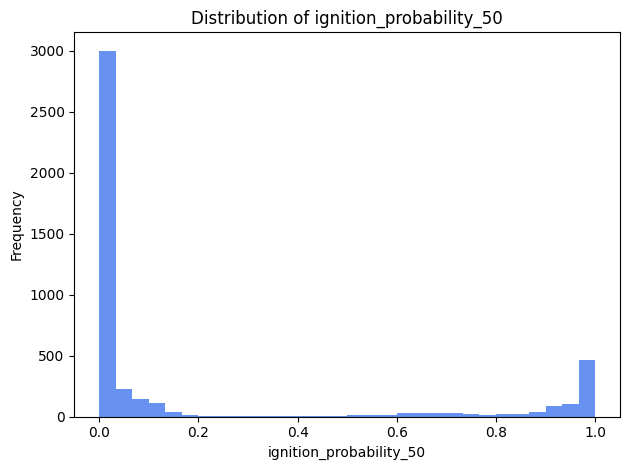

['pref_attachment', 'bridge_probability', 'approx_diameter', 'avg_local_clustering', 'avg_neighbor_degree_max', 'avg_neighbor_degree_mean', 'avg_neighbor_degree_median', 'avg_neighbor_degree_min', 'avg_neighbor_degree_q25', 'avg_neighbor_degree_q75', 'avg_neighbor_degree_skew', 'avg_neighbor_degree_std', 'coreness_max', 'coreness_mean', 'coreness_median', 'coreness_min', 'coreness_q25', 'coreness_q75', 'coreness_skew', 'coreness_std', 'density', 'detected_community_density_by_size_inter_max', 'detected_community_density_by_size_inter_mean', 'detected_community_density_by_size_inter_median', 'detected_community_density_by_size_inter_min', 'detected_community_density_by_size_inter_q25', 'detected_community_density_by_size_inter_q75', 'detected_community_density_by_size_inter_skew', 'detected_community_density_by_size_inter_std', 'detected_community_density_by_size_intra_max', 'detected_community_density_by_size_intra_mean', 'detected_community_density_by_size_intra_median', 'detected_com

,ignition_probability_50,threshold_value,pref_attachment,bridge_probability,approx_diameter,avg_local_clustering,avg_neighbor_degree_max,avg_neighbor_degree_mean,avg_neighbor_degree_median,avg_neighbor_degree_min,...,total_degree_max,total_degree_mean,total_degree_median,total_degree_min,total_degree_q25,total_degree_q75,total_degree_skew,total_degree_std,seed,random
1,0.00,0.3,0,0.0,10.0,0.604511,395.653061,69.173508,53.641026,2.0,...,573.0,51.169882,40.0,1.0,28.0,55.0,4.817936,57.027517,42,3
2,0.00,0.3,0,0.0,11.0,0.636967,418.727273,73.675088,56.724138,1.0,...,503.0,51.604292,40.0,1.0,26.0,58.0,4.848387,59.484483,42,3
5,0.00,0.3,0,0.0,14.0,0.567919,222.277778,66.572771,56.653846,4.0,...,332.0,50.896151,43.0,2.0,30.0,58.0,2.917378,40.346664,42,5
6,0.94,0.3,0,0.0,15.0,0.559965,191.382979,68.146423,55.363636,31.0,...,302.0,50.884316,42.0,6.0,32.0,55.0,3.438088,38.876439,42,4
8,0.00,0.3,0,0.0,21.0,0.705782,248.500000,81.013865,67.793103,6.0,...,374.0,50.931689,42.0,1.0,28.0,58.0,3.182182,43.579669,42,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13483,0.00,0.3,0,0.0,11.0,0.623674,428.000000,54.751794,42.607881,2.0,...,440.0,45.618725,32.0,1.0,16.0,58.0,4.338616,54.354760,42,1
13488,0.00,0.3,0,0.0,22.0,0.571685,185.481481,67.169330,62.838710,10.0,...,228.0,50.896151,44.0,1.0,30.0,56.0,2.166087,35.217521,42,5
13492,0.00,0.3,0,0.0,13.0,0.431993,367.346821,73.090389,58.933333,2.0,...,445.0,45.538981,30.0,1.0,19.0,48.0,4.136677,57.620809,42,3
13494,0.05,0.3,0,0.0,13.0,0.621519,269.037037,70.831965,60.589200,2.0,...,358.0,51.020751,42.0,1.0,26.0,60.0,3.341054,44.945796,42,4


In [ ]:
outdir = Path(OUTDIR)
outdir.mkdir(parents=True, exist_ok=True)

print("Loading CSV...")
df = pd.read_parquet(PARQUET_PATH)
# df1 = pd.read_parquet(PARQUET_PATH1)

# df = pd.concat([df1, df])
# df = df.loc[:, ~df.columns.duplicated()]
# df = df[df.optimize == 1]
if LAYER:
    df = df[df.network_id.str.contains(LAYER)]
print(df)
# df = df[df["network_id"].str.count("_") > 6]
plt.hist(df[TARGET_COL], bins=30, color="#2563eb", alpha=0.7)
plt.xlabel(f"{TARGET_COL}")
plt.ylabel("Frequency")
plt.title(f"Distribution of {TARGET_COL}")
plt.tight_layout(); plt.savefig(outdir / "target_distribution.png", dpi=130)
plt.show()

df["random"] = np.random.randint(1, 6, df.shape[0])
feats = []
for count, i in enumerate(df.columns):
    if count > 14 and not (
        "werkschool" in i or 
        "familie"  in i or 
        "huishouden"  in i or
        "assigned" in i or
        "mix_" in i or
        "transitivity" in i or
        "num_communities" in i or
        "reciprocity" in i or 
        "n_communities" in i or
        "refine_loss_goal" in i or
        "refine_loss" in i or 
        "density_by_degree" in i or
        "density_by_size" in i or
        "time" in i or
        "optimize" in i or
        "max_coreness" in i or
        "density_by_minsize" in i):

        feats.append(i)

print(feats)


keep = df[[TARGET_COL, THRESHOLD_COL] + feats].apply(pd.to_numeric,
                                                     errors="coerce").dropna()

# 2. See how many NAs are in each column
print("Nulls per column after coercion:")
print(keep.isna().sum().sort_values())

# 3. See how many rows you started with for context
print(f"\nTotal rows: {len(keep)}")

keep

## Run per threshold

In [ ]:
manifest = {"csv": PARQUET_PATH, "target": TARGET_COL, "seeds": SEEDS, "blocks": {}}

print(keep[THRESHOLD_COL].unique())
for tv in sorted(keep[THRESHOLD_COL].unique()):
    sl = keep[keep[THRESHOLD_COL] == tv]
    block_feats = [f for f in feats if sl[f].nunique() > 1]
    if len(sl) < MIN_SLICE or len(block_feats) < 2:
        print(f"[skip] threshold {tv}: N={len(sl)}, {len(block_feats)} feats")
        continue
    bdir = outdir / f"threshold_{tv}"
    bdir.mkdir(parents=True, exist_ok=True)
    print(f"\n{'='*50}\nthreshold {tv} (N={len(sl)})\n{'='*50}")
    manifest["blocks"][f"threshold_{tv}"] = {
        "threshold_value": float(tv),
        **run_slice(sl[block_feats], sl[TARGET_COL], bdir)}


[0.3]

threshold 0.3 (N=4498)
=== seed 0 ===
=== shap importance ===
=== cluster keep ===
=== ablation ===
['detected_community_edges_inter_std', 'detected_community_edges_inter_mean', 'detected_community_n_observed', 'detected_community_density_by_size_intra_mean', 'coreness_std', 'detected_community_density_by_size_intra_max', 'detected_community_edges_intra_median', 'coreness_mean', 'detected_community_edges_inter_skew', 'detected_community_density_by_size_inter_skew', 'avg_neighbor_degree_min', 'local_clustering_std', 'detected_community_density_by_size_inter_mean', 'log_out_degree_mean', 'approx_diameter', 'pagerank_std', 'global_clustering', 'pagerank_skew', 'nodes', 'pagerank_min', 'frac_in_lscc', 'detected_community_density_by_size_intra_min', 'modularity', 'local_clustering_min', 'coreness_min', 'local_clustering_q75', 'detected_community_edges_inter_max', 'out_degree_median', 'coreness_median', 'avg_neighbor_degree_q75', 'detected_community_density_by_size_intra_std', 'local_

## Write manifest